##Introduction
The dataset from kaggle with several columns and rows is used to predict the customers who likely will churn from the service.

The plan is:

EDA, Cleaning

Visualisation

Feature Creation

Train Validation Test splitting

Training 4 models (Logistic Regression, Decision Tree, Random Forest, XGBoost Classifier)

Comparing the models

Identfying the best one.

In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score,classification_report)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("customer_churn_dataset.csv")

## EDA, Cleaning, Visualisation, Feauture Creation

In [2]:
df.shape

(50000, 7)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tenure_months           50000 non-null  int64  
 1   monthly_usage_hours     50000 non-null  float64
 2   has_multiple_devices    50000 non-null  int64  
 3   customer_support_calls  50000 non-null  int64  
 4   payment_failures        50000 non-null  int64  
 5   is_premium_plan         50000 non-null  int64  
 6   churn                   50000 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 2.7 MB


In [4]:
df.head()

,tenure_months,monthly_usage_hours,has_multiple_devices,customer_support_calls,payment_failures,is_premium_plan,churn
0,39,30.953928,0,1,0,0,0
1,52,20.485203,0,0,0,0,0
2,29,21.684462,0,1,1,0,0
3,15,27.894281,0,1,0,1,0
4,43,19.250190,1,1,0,0,0


In [5]:
df.describe()

,tenure_months,monthly_usage_hours,has_multiple_devices,customer_support_calls,payment_failures,is_premium_plan,churn
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,30.029760,20.000411,0.39882,1.205680,0.098780,0.298340,0.020660
std,16.997771,4.996693,0.48966,1.101236,0.298369,0.457534,0.142245
min,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,16.589750,0.00000,0.000000,0.000000,0.000000,0.000000
50%,30.000000,20.026256,0.00000,1.000000,0.000000,0.000000,0.000000
75%,45.000000,23.387508,1.00000,2.000000,0.000000,1.000000,0.000000
max,59.000000,38.726896,1.00000,8.000000,1.000000,1.000000,1.000000


In [6]:
print(df.isnull().sum())
print(df.duplicated().sum())
#There are no any missing and duplicated values

tenure_months             0
monthly_usage_hours       0
has_multiple_devices      0
customer_support_calls    0
payment_failures          0
is_premium_plan           0
churn                     0
dtype: int64
0


Checking Unique Values

In [7]:
unique_values_devices = df["has_multiple_devices"].unique()
print("\nUnique values of the column 'has_multiple_devices'",unique_values_devices)

unique_values_calls = df["customer_support_calls"].unique()
counted_values_calls = df["customer_support_calls"].value_counts()
print("\nUnique values of the column 'customer_support_calls'",unique_values_calls)
print("\nCounted values of it",counted_values_calls)


unique_values_phone = df["payment_failures"].unique()
print("\nUnique values of the column 'payment_failures'",unique_values_phone)


Unique values of the column 'has_multiple_devices' [0 1]

Unique values of the column 'customer_support_calls' [1 0 2 5 3 4 6 7 8]

Counted values of it customer_support_calls
1    17973
0    15042
2    10876
3     4384
4     1312
5      334
6       66
7       11
8        2
Name: count, dtype: int64

Unique values of the column 'payment_failures' [0 1]


Visualisation for better understanding

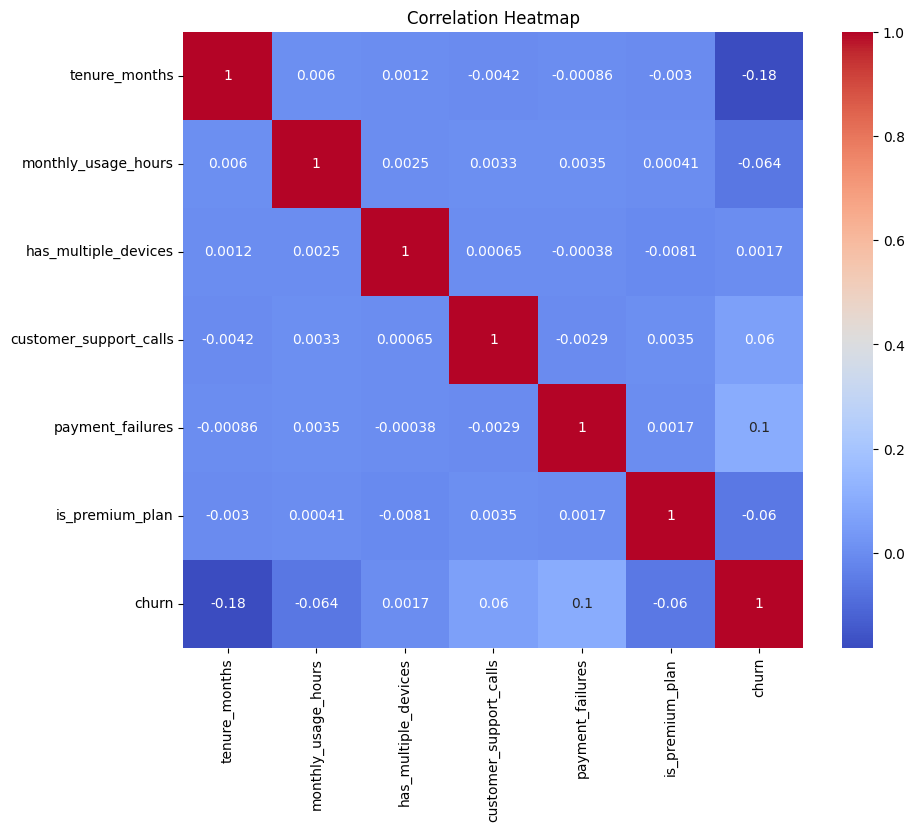

In [8]:
correleation = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correleation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

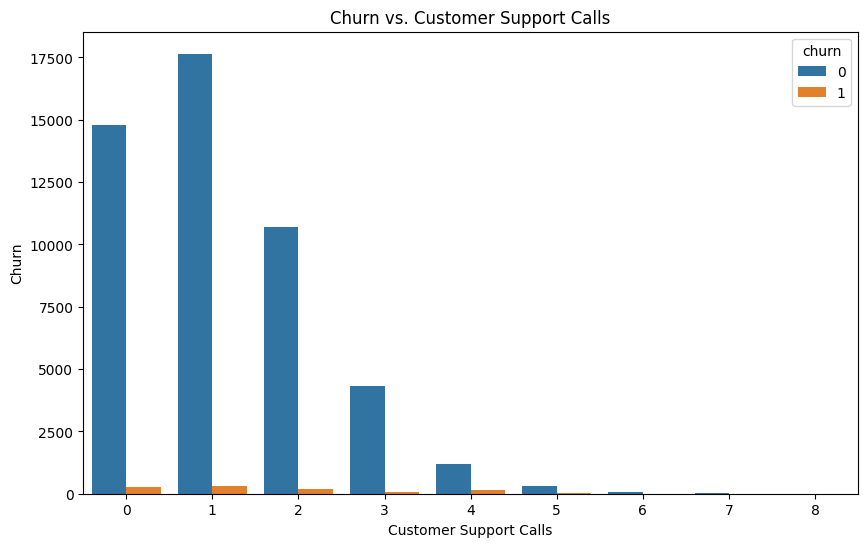

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="customer_support_calls", hue="churn")
plt.title("Churn vs. Customer Support Calls")
plt.xlabel("Customer Support Calls")
plt.ylabel("Churn")
plt.show()

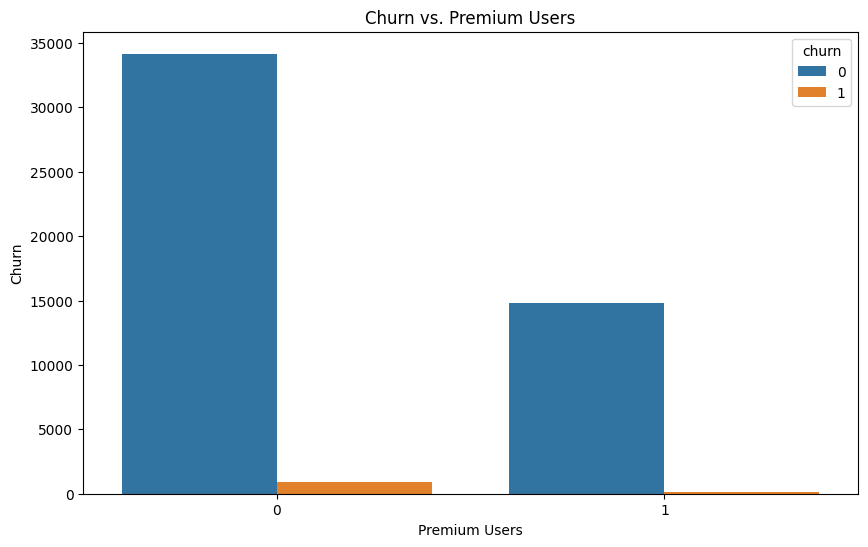

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="is_premium_plan", hue="churn")
plt.title("Churn vs. Premium Users")
plt.xlabel("Premium Users")
plt.ylabel("Churn")
plt.show()

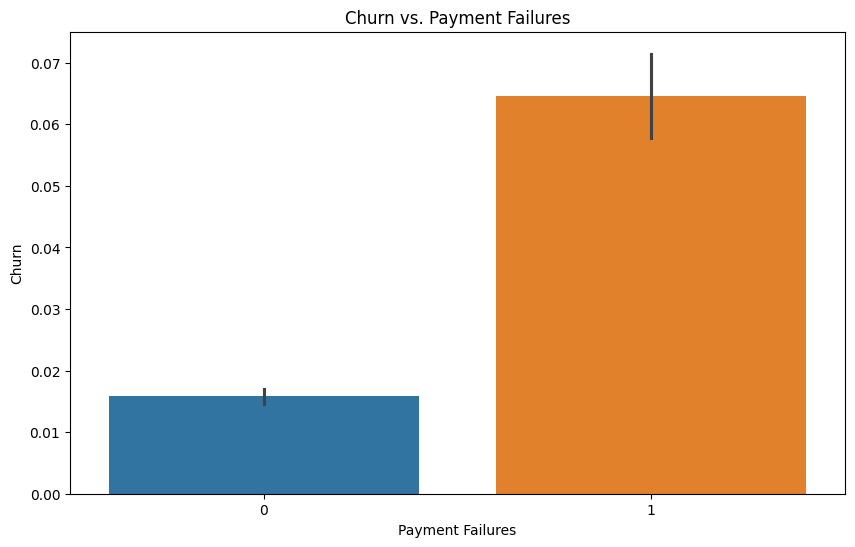

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="payment_failures", y="churn", legend = False, hue = "payment_failures")
plt.title("Churn vs. Payment Failures")
plt.xlabel("Payment Failures")
plt.ylabel("Churn")
plt.show()


## Creating new features

In [12]:
df["customer_ranking"] = pd.cut(
    df["tenure_months"],
    bins=[-1, 3, 12, 24, np.inf],
    labels=["new", "regular", "loyal", "veteran"]
) #ranks the customer based on their tenure months
df["total_hours_used"] = df["tenure_months"] * df["monthly_usage_hours"] #shows total hours using the service
df["premium_users_usage_hours"] = df["total_hours_used"] * df["is_premium_plan"] #shows the hours used by premium users, identifying the ones who can potentially churn
df["payment_risk_score"] = df["payment_failures"] + df["customer_support_calls"] #shows overall issues happened with particular customer
df["problem_occurrence"] = df["payment_risk_score"] / (df["tenure_months"] + 1) #shows problems per month for
df["customers_need_help"] = df["customer_support_calls"] > 1 #shows the customers who need help asap, 1 was chosen as after one call, people tend to churn more
df["support_calls_per_month"] = df["customer_support_calls"] / (df["tenure_months"] + 1) #support calls per month


/tmp/ipykernel_581/3160144085.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_tenure_vs_churn = df.groupby("customer_ranking")["churn"]


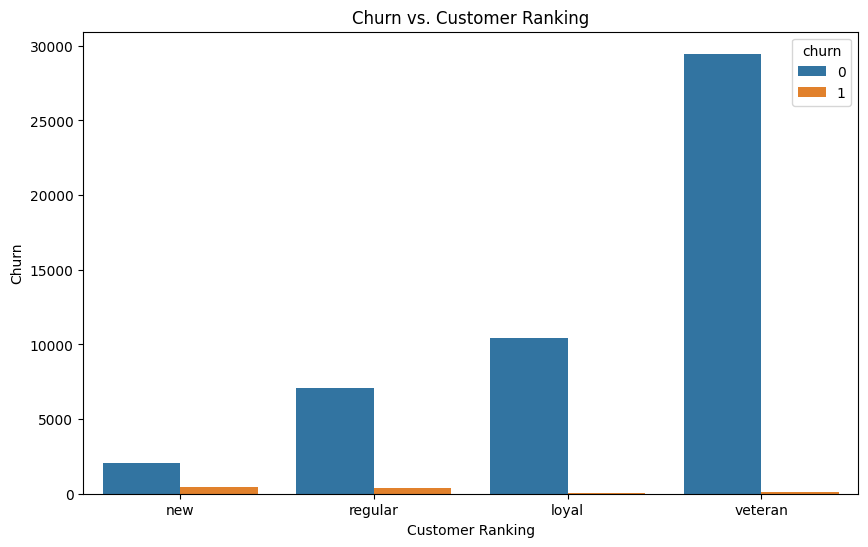

In [13]:
customer_tenure_vs_churn = df.groupby("customer_ranking")["churn"]

plt.figure(figsize=(10,6))
sns.countplot(data=df, x="customer_ranking", hue="churn")
plt.title("Churn vs. Customer Ranking")
plt.xlabel("Customer Ranking")
plt.ylabel("Churn")
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   tenure_months              50000 non-null  int64   
 1   monthly_usage_hours        50000 non-null  float64 
 2   has_multiple_devices       50000 non-null  int64   
 3   customer_support_calls     50000 non-null  int64   
 4   payment_failures           50000 non-null  int64   
 5   is_premium_plan            50000 non-null  int64   
 6   churn                      50000 non-null  int64   
 7   customer_ranking           50000 non-null  category
 8   total_hours_used           50000 non-null  float64 
 9   premium_users_usage_hours  50000 non-null  float64 
 10  payment_risk_score         50000 non-null  int64   
 11  problem_occurrence         50000 non-null  float64 
 12  customers_need_help        50000 non-null  bool    
 13  support_calls_per_month    5000

## TRAIN TEST VALIDATION Splitting, avoiding data leakage

In [15]:
numerical_features = [
    "tenure_months",
    "monthly_usage_hours",
    "total_hours_used",
    "premium_users_usage_hours",
    "payment_failures",
    "customer_support_calls",
    "payment_risk_score",
    "problem_occurrence",
    "support_calls_per_month"
]

categorical_features = [
    "customer_ranking"
]


In [16]:

X = df.drop(columns=["churn"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42, stratify = y_train)

#Using ColumnTransformer and Pipeline for more convenience

preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder = "passthrough"
)

Logistic Regression

In [17]:
log_reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter = 1000,
        random_state = 42,
        class_weight = "balanced",
    ))
])
log_reg_model.fit(X_train, y_train)
y_pred = log_reg_model.predict(X_val)
y_prob = log_reg_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print(f"Accuracy: {accuracy_score(y_val, y_pred)}")
print(f"ROC-AUC score: {roc_auc_score(y_val, y_prob)}")

              precision    recall  f1-score   support

           0       1.00      0.84      0.91      7835
           1       0.11      0.90      0.19       165

    accuracy                           0.84      8000
   macro avg       0.55      0.87      0.55      8000
weighted avg       0.98      0.84      0.90      8000

Accuracy: 0.841625
ROC-AUC score: 0.9360607994430585


Decision Tree

In [18]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth = 10,
        random_state = 42,
        class_weight="balanced"
    ))
])
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_val)
y_prob = tree_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print(f"Accuracy: {accuracy_score(y_val, y_pred)}")
print(f"ROC-AUC score: {roc_auc_score(y_val, y_prob)}")

              precision    recall  f1-score   support

           0       1.00      0.93      0.96      7835
           1       0.20      0.79      0.32       165

    accuracy                           0.93      8000
   macro avg       0.60      0.86      0.64      8000
weighted avg       0.98      0.93      0.95      8000

Accuracy: 0.930375
ROC-AUC score: 0.8751464872077508


Random Forest

In [19]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators = 300,
        max_depth = 5,
        random_state = 42,
        class_weight = "balanced"
    ))
])
rf_model.fit(X_train, y_train)
rf_model_pred = rf_model.predict(X_val)
rf_model_prob = rf_model.predict_proba(X_val)[:, 1]


print(classification_report(y_val, rf_model_pred))
print(f"Accuracy: {accuracy_score(y_val, rf_model_pred)}")
print(f"ROC-AUC score: {roc_auc_score(y_val, rf_model_prob)}")

              precision    recall  f1-score   support

           0       1.00      0.91      0.95      7835
           1       0.18      0.93      0.30       165

    accuracy                           0.91      8000
   macro avg       0.59      0.92      0.63      8000
weighted avg       0.98      0.91      0.94      8000

Accuracy: 0.910375
ROC-AUC score: 0.965791804451664


XGBoost Classifier

In [20]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = Pipeline ([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        scale_pos_weight = scale_pos_weight,
        n_estimators = 700,
        max_depth = 5,
        random_state = 42,
        learning_rate = 0.01,
        eval_metric="auc"
    ))
])
xgb_model.fit(X_train, y_train)

xgb_model_prob = xgb_model.predict_proba(X_val)[:, 1]
xgb_pred = (xgb_model_prob > 0.7).astype(int)

for threshold in [0.3, 0.5, 0.6, 0.7, 0.8]:
    pred = (xgb_model_prob > threshold).astype(int)

    print("Threshold:", threshold)
    print(classification_report(y_val, pred))

print(classification_report(y_val, xgb_pred))
print(f"Accuracy: {accuracy_score(y_val, xgb_pred)}")
print(f"ROC-AUC score: {roc_auc_score(y_val, xgb_model_prob)}")

Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      7835
           1       0.17      0.94      0.29       165

    accuracy                           0.91      8000
   macro avg       0.59      0.92      0.62      8000
weighted avg       0.98      0.91      0.94      8000

Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      7835
           1       0.20      0.90      0.33       165

    accuracy                           0.93      8000
   macro avg       0.60      0.91      0.65      8000
weighted avg       0.98      0.93      0.95      8000

Threshold: 0.6
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      7835
           1       0.22      0.88      0.35       165

    accuracy                           0.93      8000
   macro avg       0.61      0.91      0.66      8000
weighted avg       0.98      

## Comparison Table

In [21]:
def comparison_matrix(name, model, X_data, y_data):
    y_prob = model.predict_proba(X_data)[:, 1]
    y_pred = model.predict(X_data)
    return{
        "Model": name,
        "Accuracy": accuracy_score(y_data, y_pred),
        "Precision": precision_score(y_data, y_pred),
        "Recall": recall_score(y_data, y_pred),
        "F1 Score": f1_score(y_data, y_pred),
        "ROC-AUC Score": roc_auc_score(y_data, y_prob)
    }
comparison_table = pd.DataFrame([
    comparison_matrix("Logistic Regression", log_reg_model, X_val, y_val),
    comparison_matrix("Decision Tree", tree_model, X_val, y_val),
    comparison_matrix("Random Forest", rf_model, X_val, y_val),
    comparison_matrix("XGBoost", xgb_model, X_val, y_val)
]).sort_values(by="ROC-AUC Score", ascending=False)

comparison_table.round(2)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC Score
3,XGBoost,0.92,0.20,0.90,0.33,0.97
2,Random Forest,0.91,0.18,0.93,0.30,0.97
0,Logistic Regression,0.84,0.11,0.90,0.19,0.94
1,Decision Tree,0.93,0.20,0.79,0.32,0.88


[[7379  456]
 [  22  143]]


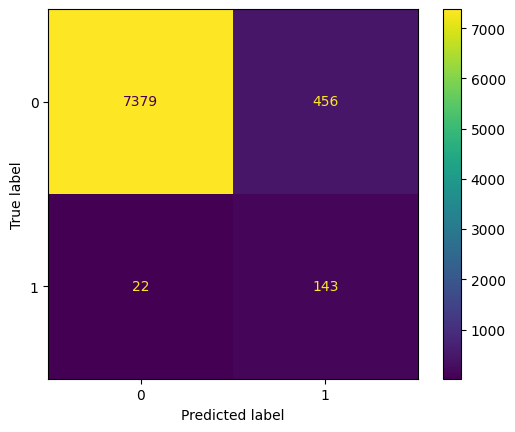

In [22]:
cm = confusion_matrix(y_val, xgb_pred)

print(cm)
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    xgb_pred
)

plt.show()

In [23]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="auc"
    ))
])

param_dist = {
    "classifier__n_estimators": [200, 400, 700, 1000],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.85, 1.0],
    "classifier__colsample_bytree": [0.7, 0.85, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV PR-AUC:", search.best_score_)

xgb_model = search.best_estimator_

Best params: {'classifier__subsample': 1.0, 'classifier__n_estimators': 400, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.7}
Best CV PR-AUC: 0.5451959731385934


One more time testing the model with the test set that was separated at the beginning.  

Depends on the preferences of the company, which threshold to choose, based on which category is more costly and etc, therefore, in this case 0.7 threshold has been chosen for a higher recall, without comprimising too much on precision

In [30]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=400,       # from search.best_params_
        max_depth=3,
        learning_rate=0.03,
        subsample=1.0,
        colsample_bytree=0.7,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="auc"
    ))
])
xgb_model.fit(X_train, y_train)

xgb_model_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_model_prob > 0.7).astype(int)

print(classification_report(y_test, xgb_pred))
print(f"Accuracy: {accuracy_score(y_test, xgb_pred)}")
print(f"ROC-AUC score: {roc_auc_score(y_test, xgb_model_prob)}")
print(f"F1 Score: {f1_score(y_test, xgb_pred)}")
print(f"Precision: {precision_score(y_test, xgb_pred)}")
print(f"Recall: {recall_score(y_test, xgb_pred)}")

              precision    recall  f1-score   support

           0       1.00      0.93      0.96      9793
           1       0.22      0.93      0.36       207

    accuracy                           0.93     10000
   macro avg       0.61      0.93      0.66     10000
weighted avg       0.98      0.93      0.95     10000

Accuracy: 0.9321
ROC-AUC score: 0.9740924578386119
F1 Score: 0.36124176857949203
Precision: 0.22429906542056074
Recall: 0.927536231884058


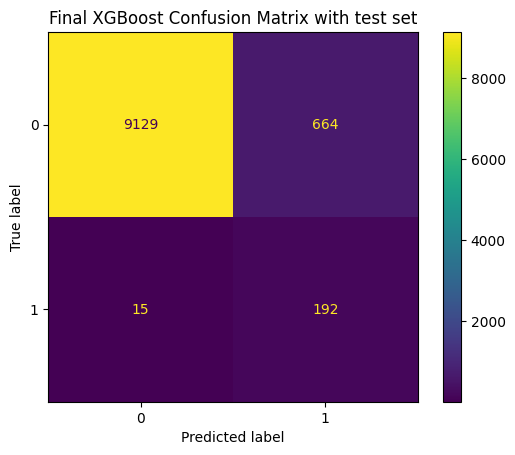

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred
)

plt.title("Final XGBoost Confusion Matrix with test set")
plt.show()

## Feature Importances & SHAP & New Correlation

[0.18475826 0.07137586 0.09230027 0.01914107 0.03769211 0.0530333
 0.08447257 0.05664804 0.01385539 0.00154228 0.34639174 0.01013383
 0.00195008 0.00746242 0.01721108 0.00203174]
                            feature  importance
10        cat__customer_ranking_new    0.346392
0                num__tenure_months    0.184758
2             num__total_hours_used    0.092300
6           num__payment_risk_score    0.084473
1          num__monthly_usage_hours    0.071376
7           num__problem_occurrence    0.056648
5       num__customer_support_calls    0.053033
4             num__payment_failures    0.037692
3    num__premium_users_usage_hours    0.019141
14       remainder__is_premium_plan    0.017211
8      num__support_calls_per_month    0.013855
11    cat__customer_ranking_regular    0.010134
13  remainder__has_multiple_devices    0.007462
15   remainder__customers_need_help    0.002032
12    cat__customer_ranking_veteran    0.001950


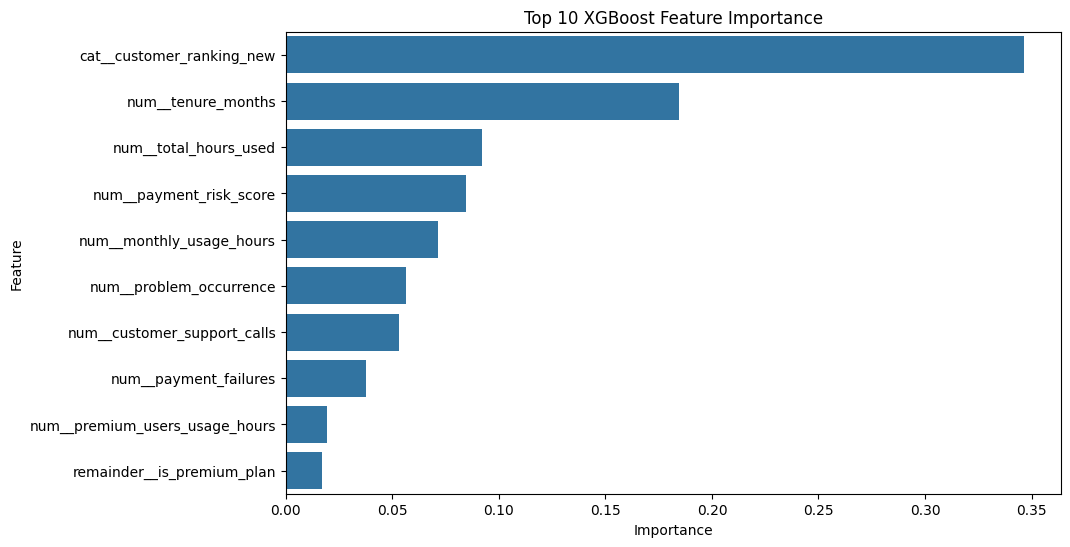

In [32]:
importance = xgb_model.named_steps["classifier"].feature_importances_

print(importance)

feature_names = (
    xgb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance.head(15))

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

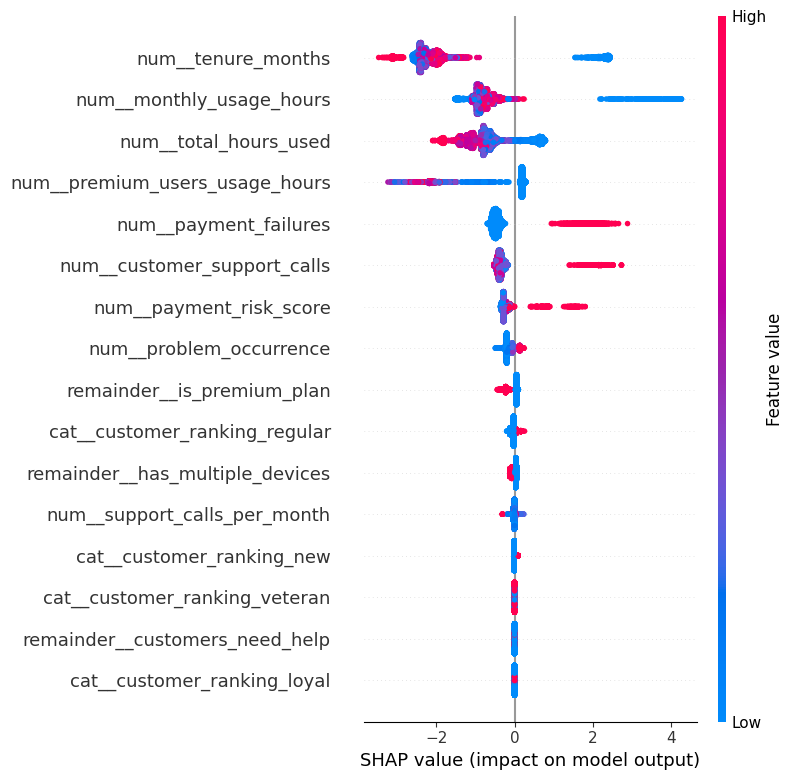

In [33]:
import shap
xgb_classifier = xgb_model.named_steps["classifier"]

X_val_transformed = (
    xgb_model
    .named_steps["preprocessor"]
    .transform(X_val)
)

feature_names = (
    xgb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

explainer = shap.TreeExplainer(xgb_classifier)

shap_values = explainer.shap_values(X_val_transformed)

shap.summary_plot(
    shap_values,
    X_val_transformed,
    feature_names=feature_names
)

After SHAP and feature importances, we can see that features (tenure_months, premium_users_hours, monthly_usage_hours, num_payment_risk_score, payment failures, support calls) are having most effect on the potential churn of the customers. For instance, payment failures and support calls strongly impact the decision of the customers, and they might churn, while red dots of the tenure months and usage hours, show that the more they use the service, the less chances there will be that our customers will churn.

updated correlation matrix

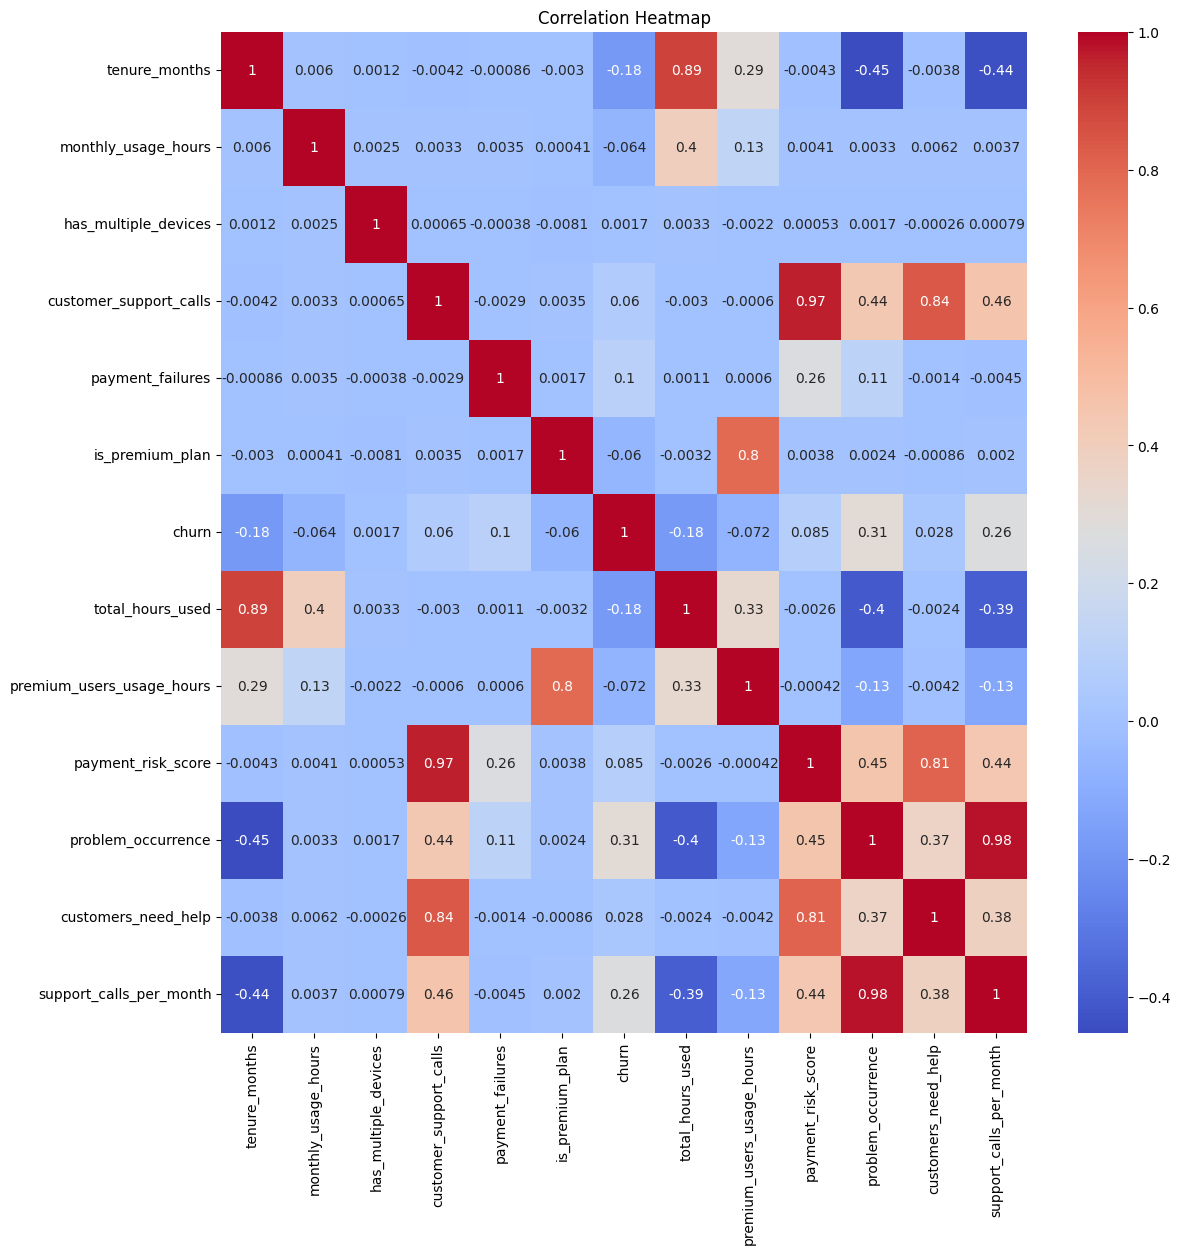

In [34]:
correleation = df.corr(numeric_only=True)

plt.figure(figsize=(13, 13))
sns.heatmap(correleation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [35]:
import joblib

joblib.dump({"model": xgb_model, "threshold": 0.7}, "xgb_model.pkl")
loaded_model = joblib.load("xgb_model.pkl")